# Exercise Sheet: Machine Learning with the California Housing Dataset

Duration: ~4 hours

Level: Master’s (physics / data science)

Tools: Python, pandas, matplotlib, scikit-learn


## Learning goals

By the end of this session, you should be able to:

- Load and explore real-world datasets
- Understand feature distributions and correlations
- Prepare data for machine learning
- Train and evaluate regression models
- Interpret model performance and limitations

## Part 0 - Setup (15 min)
Exercise 0.1 - Download and load the dataset

Use the provided code to:

- Download the dataset
- Extract it
- Load it into a pandas DataFrame

### Task

Print the first 5 rows
Check the shape of the dataset

In [468]:
import os
import tarfile
import urllib.request
import pandas as pd
import matplotlib as plt

# -----------------------------------------------------------
# URL of the dataset (compressed .tgz file from GitHub)
# -----------------------------------------------------------
HOUSING_URL = "https://github.com/ageron/data/raw/main/housing.tgz"

# -----------------------------------------------------------
# Define local directories and file paths
# -----------------------------------------------------------
DOWNLOAD_DIR = "datasets"                     # main folder for all datasets
TGZ_PATH = os.path.join(DOWNLOAD_DIR, "housing.tgz")  # path to downloaded file
EXTRACT_DIR = os.path.join(DOWNLOAD_DIR, "housing")   # where CSV will be extracted

# -----------------------------------------------------------
# Function to download and extract the dataset
# -----------------------------------------------------------
def download_and_extract_data(url=HOUSING_URL, tgz_path=TGZ_PATH, extract_dir=EXTRACT_DIR):
    
    # Create the dataset directory if it does not exist
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)

    # -------------------------------------------------------
    # Download step (ONLY if file does not already exist)
    # -------------------------------------------------------
    if not os.path.exists(tgz_path):
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, tgz_path)
        print("Download complete.")
    else:
        print("Dataset already downloaded. Skipping download.")

    # -------------------------------------------------------
    # Extraction step (ONLY if not already extracted)
    # -------------------------------------------------------
    if not os.path.exists(extract_dir):
        print("Extracting dataset...")
        with tarfile.open(tgz_path) as tar:
            tar.extractall(path=DOWNLOAD_DIR)
        print("Extraction complete.")
    else:
        print("Dataset already extracted. Skipping extraction.")

# -----------------------------------------------------------
# Function to load the CSV into a pandas DataFrame
# -----------------------------------------------------------
def load_housing_data(csv_path=os.path.join(EXTRACT_DIR, "housing.csv")):
    
    # Check if file exists before loading
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"CSV file not found at {csv_path}. "
            "Make sure the dataset is downloaded and extracted."
        )

    print("Loading dataset into pandas DataFrame...")
    df = pd.read_csv(csv_path)

    return df

    
# Step 1: Download and extract dataset (if needed)
download_and_extract_data()

# Step 2: Load dataset into pandas
housing_df = load_housing_data()

# Step 3: Basic inspection
housing_df.head()



Dataset already downloaded. Skipping download.
Dataset already extracted. Skipping extraction.
Loading dataset into pandas DataFrame...


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Exercise 0.2 — Basic inspection

Questions

- How many features are there?
- What are their names?
- Which feature is the target variable?



We can check for `ocean_proximity` since its type is object, while others are numerical

In [469]:
# Info
print("\n Dataset info")
housing_df.info()
housing_df.dtypes
housing_df.describe()


 Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [470]:
# Proximity Test
prox = housing_df["ocean_proximity"]
prox.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

We can check the summary of the numerical attributes

## Part 1 — Data Exploration (45 min)

### Exercise 1.1 — Visualizing distributions

Plot histograms of all features:

Questions

- Which variables are skewed?
- Are there outliers?
- Which feature looks discretized?

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

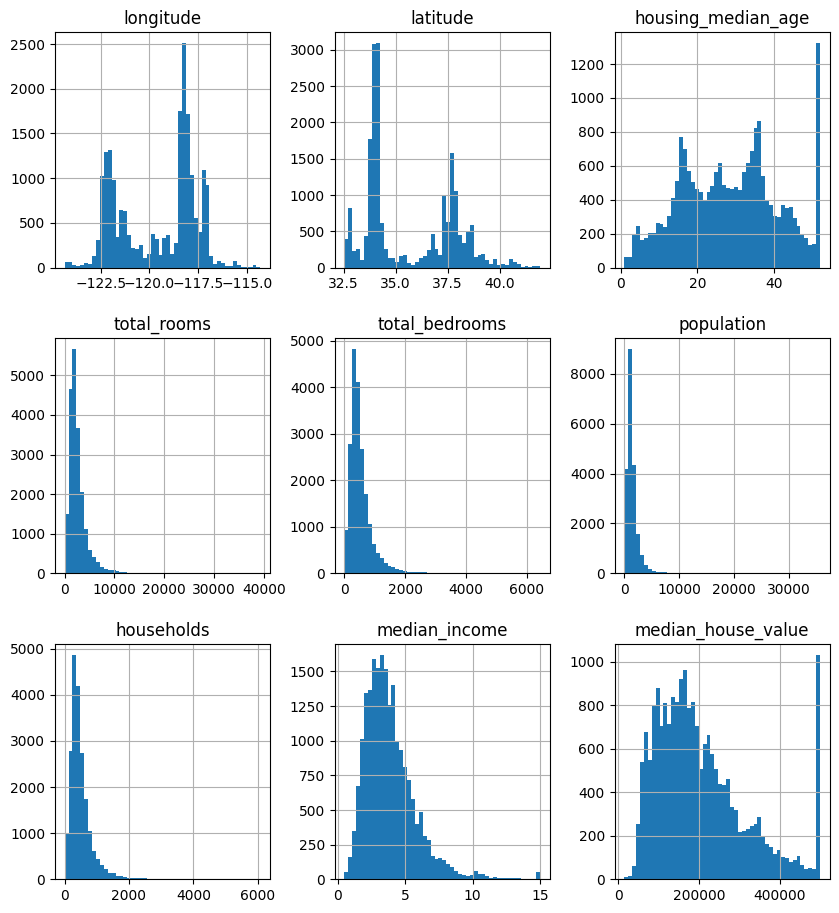

In [471]:
#Plot for features
housing_df.hist(bins = 50, figsize = (10,11))


### Exercise 1.2 — Geographic visualization

Plot longitude vs latitude (both simple and with some beautiful colours):

Questions

- Where are the most expensive houses located?
- What patterns do you see?

<Axes: xlabel='longitude', ylabel='latitude'>

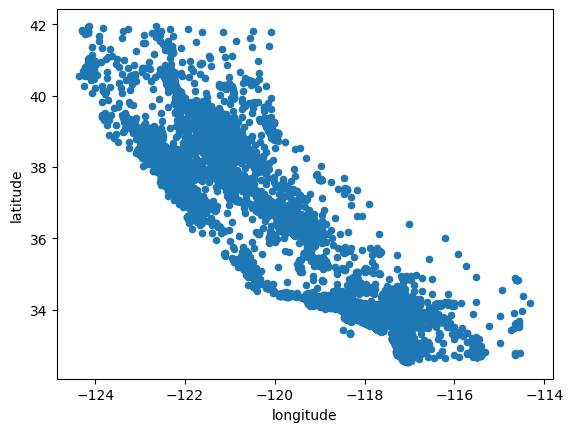

In [472]:
#Longitude vs Latitude Simple
housing_df.plot('longitude', 'latitude', kind = 'scatter')

<Axes: xlabel='longitude', ylabel='latitude'>

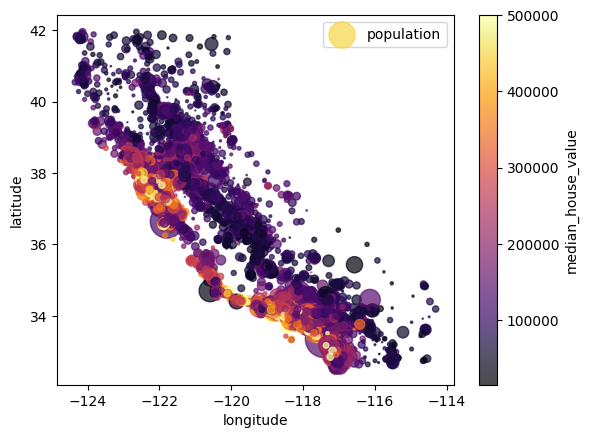

In [473]:
#Longitude vs Latitude Fancy
housing_df.plot('longitude', 'latitude', c ='median_house_value', kind = 'scatter', s = housing_df['population']/50, alpha = 0.7, cmap = 'inferno', label = 'population')

### Exercise 1.3 — Correlation analysis

Compute correlation matrix:

Task

Find the features most correlated with median_house_value

Question

Which variable is the strongest predictor?

In [474]:
housing_df.corr(method = 'pearson', min_periods = 1, numeric_only = True)
#Median Income


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


## Part 2 - Data Preparation (60 min)
### Exercise 2.1 - Train/test split

Split data:

Question

Why do we split the dataset?

In [475]:
import numpy as np
np.array_split(housing_df, 3)

[array([[-122.23, 37.88, 41.0, ..., 8.3252, 452600.0, 'NEAR BAY'],
        [-122.22, 37.86, 21.0, ..., 8.3014, 358500.0, 'NEAR BAY'],
        [-122.24, 37.85, 52.0, ..., 7.2574, 352100.0, 'NEAR BAY'],
        ...,
        [-122.1, 37.89, 21.0, ..., 5.2079, 310300.0, 'NEAR BAY'],
        [-117.01, 32.79, 33.0, ..., 4.3152, 159300.0, '<1H OCEAN'],
        [-122.29, 37.51, 35.0, ..., 6.1004, 426400.0, 'NEAR OCEAN']],
       shape=(6880, 10), dtype=object),
 array([[-122.5, 37.76, 48.0, ..., 3.8333, 296300.0, 'NEAR OCEAN'],
        [-119.24, 35.68, 21.0, ..., 2.5208, 58500.0, 'INLAND'],
        [-118.09, 34.05, 22.0, ..., 3.5357, 199000.0, '<1H OCEAN'],
        ...,
        [-121.04, 39.22, 14.0, ..., 2.25, 112500.0, 'INLAND'],
        [-121.35, 38.4, 11.0, ..., 3.175, 94400.0, 'INLAND'],
        [-117.91, 33.71, 16.0, ..., 3.6505, 145700.0, '<1H OCEAN']],
       shape=(6880, 10), dtype=object),
 array([[-122.67, 38.44, 29.0, ..., 4.3587, 196400.0, '<1H OCEAN'],
        [-118.19, 34.06, 44

### Exercise 2.2 — Stratified sampling

Create income categories:

Plot it

What is stratified sampling (intuition)

Instead of splitting your dataset randomly, you split it in a way that preserves the distribution of an important variable.

In this dataset, that variable is:
`median_income`

Why do we care here?

House prices depend strongly on income.

If you do a purely random split:

- you might accidentally get too many rich districts in train
- and too many poor districts in test

Result: your model evaluation becomes biased / unreliable

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
housing_df['median_income'] = pd.cut(housing_df['median_income'])
X_train, X_test, y_train, y_test= train_test_split(housing_df,housing_df["median_income"], test_size = 0.2, stratify = housing_df["median_income"])

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [0.5495, 0.6433, 0.6775, 0.6825, 0.6831, 0.696, 0.6991, 0.7007, 0.7025, 0.7054, 0.7068, 0.7069, 0.7075, 0.716, 0.7235, 0.7286, 0.7403, 0.7445, 0.7473, 0.75, 0.7526, 0.7591, 0.76, 0.7683, 0.7684, 0.7685, 0.7714, 0.78, 0.7917, 0.799, 0.8012, 0.8024, 0.8026, 0.8054, 0.8056, 0.8075, 0.8106, 0.813, 0.8131, 0.8172, 0.8185, 0.8198, 0.8229, 0.8246, 0.8252, 0.8288, 0.8351, 0.8362, 0.8438, 0.844, 0.8478, 0.8527, 0.8543, 0.8571, 0.8585, 0.8639, 0.8641, 0.8658, 0.8668, 0.8691, 0.8702, 0.8738, 0.8804, 0.8836, 0.8894, 0.8907, 0.8926, 0.8928, 0.8952, 0.8964, 0.8984, 0.8991, 0.9, 0.9011, 0.9142, 0.9166, 0.9196, 0.9204, 0.9218, 0.922, 0.9227, 0.9234, 0.9241, 0.9274, 0.9283, 0.9288, 0.9298, 0.9304, 0.9318, 0.9336, 0.9337, 0.9338, 0.9355, 0.9365, 0.9379, 0.9393, 0.9407, 0.9437, 0.9463, 0.949, 0.9506, 0.9513, 0.9518, 0.9563, 

### Exercise 2.3 — Handling missing values

Identify missing values:

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy="median")

# Select only numerical columns
housing_num = housing_df.drop("ocean_proximity", axis=1)

# Fit + transform
housing_num_imputed = imputer.fit_transform(housing_num)

### Exercise 2.4 — Feature engineering

Create new features:

In [ ]:
housing_df["rooms_per_household"] = housing_df["total_rooms"] / housing_df["households"]
housing_df["bedrooms_per_room"] = housing_df["total_bedrooms"] / housing_df["total_rooms"]
housing_df["population_per_household"] = housing_df["population"] / housing_df["households"]

Question

Why might these features help?

### Exercise 2.5 — Categorical variables

Encode ocean_proximity:

In [ ]:
# Remove the helper column used only for stratification
for set_ in (train_set, test_set):
    if "income_cat" in set_.columns:
        set_.drop("income_cat", axis=1, inplace=True)

# Add the engineered features to BOTH train and test sets
for set_ in (train_set, test_set):
    set_["rooms_per_household"] = set_["total_rooms"] / set_["households"]
    set_["bedrooms_per_room"] = set_["total_bedrooms"] / set_["total_rooms"]
    set_["population_per_household"] = set_["population"] / set_["households"]

# Separate inputs (X) and target (y)
X_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"].copy()

X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"].copy()

# Separate numerical and categorical columns
X_train_num = X_train.drop("ocean_proximity", axis=1)
X_test_num = X_test.drop("ocean_proximity", axis=1)

X_train_cat = X_train[["ocean_proximity"]]
X_test_cat = X_test[["ocean_proximity"]]

# Impute missing numerical values using ONLY the training set
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_num_imputed = pd.DataFrame(
    imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

# One-hot encode the categorical column using ONLY the training set
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_cat_encoded = pd.DataFrame(
    encoder.fit_transform(X_train_cat).toarray(),
    columns=encoder.get_feature_names_out(["ocean_proximity"]),
    index=X_train_cat.index
)

X_test_cat_encoded = pd.DataFrame(
    encoder.transform(X_test_cat).toarray(),
    columns=encoder.get_feature_names_out(["ocean_proximity"]),
    index=X_test_cat.index
)

# Final prepared datasets for machine learning
X_train_prepared = pd.concat([X_train_num_imputed, X_train_cat_encoded], axis=1)
X_test_prepared = pd.concat([X_test_num_imputed, X_test_cat_encoded], axis=1)

print("Training set shape:", X_train_prepared.shape)
print("Test set shape:", X_test_prepared.shape)
X_train_prepared.head()

NameError: name 'train_set' is not defined

## Part 3 - Linear Regression

### Exercise 3.1 — Look at a few predictions

New cell

Questions for students

- Are the predictions close to the true values?
- Does the model always overestimate, always underestimate, or both?
- Are there cases where the prediction error is very large?

### Exercise 3.2 — Compute residuals

Explain that the residual is: $$ residual = y_{true} - y_{cell}$$



Questions

- What does a positive residual mean?
- What does a negative residual mean?
- If residuals are centered around zero, what does that suggest?

In [ ]:
results_df["residual"].describe()

count    4.128000e+03
mean     9.938330e+02
std      7.201519e+04
min     -8.126785e+05
25%     -4.062067e+04
50%     -9.098446e+03
75%      3.114968e+04
max      1.037290e+06
Name: residual, dtype: float64

Questions

- What is the mean residual?
- Is it close to zero?
- What is the standard deviation of the residuals?

### Exercise 3.4 — Plot true vs predicted values

This is one of the best linear-regression exercises.

Questions

- What would a perfect model look like on this plot?
- Do the points follow the diagonal?
- In which region does the model perform worse?

### Exercise 3.9 — Standardize the numerical variables and retrain

Still linear regression, but now you learn why preprocessing matters.

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train_num_imputed.columns

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_imputed),
    columns=num_cols,
    index=X_train_num_imputed.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num_imputed),
    columns=num_cols,
    index=X_test_num_imputed.index
)

X_train_prepared_scaled = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_prepared_scaled = pd.concat([X_test_num_scaled, X_test_cat_encoded], axis=1)

In [ ]:
lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_prepared_scaled, y_train)

y_pred_scaled = lin_reg_scaled.predict(X_test_prepared_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))

print("Test RMSE with scaling:", rmse_scaled)

Test RMSE with scaling: 72013.32213353708
